This notebook goes through a second exploratory analysis. Now that the data has been wrangled and is in a better form, other exploratory processes for example group explorations become more insightful.

A reminder of what our data looks like:

In [41]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr, levene, f_oneway

In [38]:
df = pd.read_csv('../data/raw/shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

Product Insights

Mean purchase by category 

In [13]:
df.groupby("Category")["Purchase Amount (USD)"].mean().sort_values(ascending=False)

Category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64

2. Mean purchase amount for discounted purchases

In [46]:
df.groupby("Discount Applied")["Purchase Amount (USD)"].mean().sort_values(ascending=False)

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

Revenue brought in by discounted purchases as opposed to non-discounted purchases

In [47]:
df.groupby("Discount Applied")["Purchase Amount (USD)"].sum()

Discount Applied
No     133670
Yes     99411
Name: Purchase Amount (USD), dtype: int64

Are there significant differences in the review ratings given by customers for items purchased? 

In [ ]:
grouped_data = [group['Review Rating'].values for name, group in df.groupby('Item Purchased')]
f_stat, p_val_anova = f_oneway(*grouped_data)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.4f}")

ANOVA F-statistic: 0.8310, p-value: 0.6996


There is no statistically significant difference in the item purchased and the review rating given by a customer.

In [48]:
df["Item Purchased"].value_counts()

Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

Since 'Item Purchased' can take on so many different values, it may be easier to inspect this variable using a visualisation.

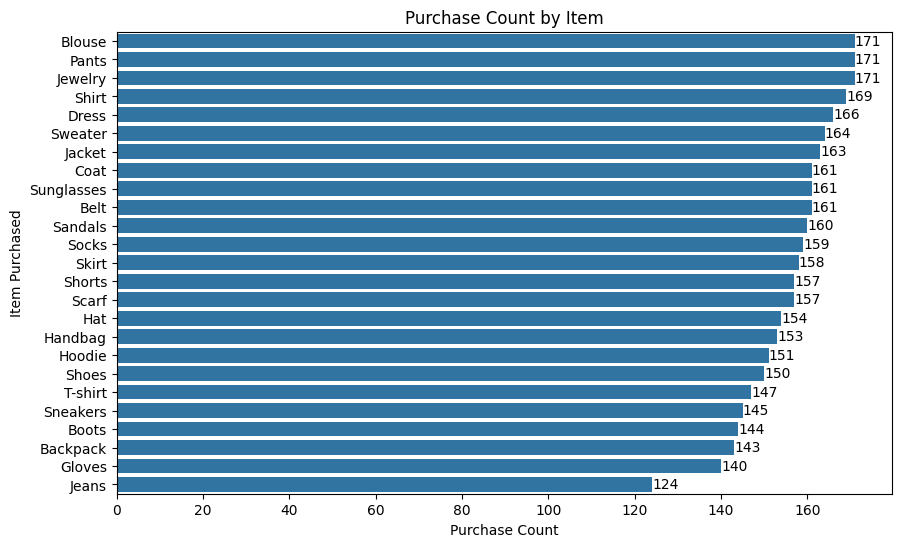

In [49]:
item_counts = (
    df["Item Purchased"]
    .value_counts()
    .reset_index()
)
item_counts.columns = ["Item Purchased", "Purchase Count"]

plt.figure(figsize=(10,6))
item_revenue=sns.barplot(x="Purchase Count", y="Item Purchased", data=item_counts, errorbar=None)
plt.title("Purchase Count by Item")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

In [50]:
df.groupby("Gender")["Item Purchased"].value_counts()

Gender  Item Purchased
Female  Blouse             66
        Shirt              59
        Sandals            59
        Handbag            58
        Socks              58
        Sunglasses         56
        Belt               55
        Jacket             54
        Dress              52
        Jewelry            52
        Hat                52
        Hoodie             51
        Boots              50
        Sweater            50
        Skirt              49
        Pants              48
        Shorts             48
        Shoes              48
        Coat               47
        T-shirt            46
        Scarf              45
        Sneakers           42
        Backpack           37
        Gloves             37
        Jeans              29
Male    Pants             123
        Jewelry           119
        Sweater           114
        Coat              114
        Dress             114
        Scarf             112
        Shirt             110
        Shorts   

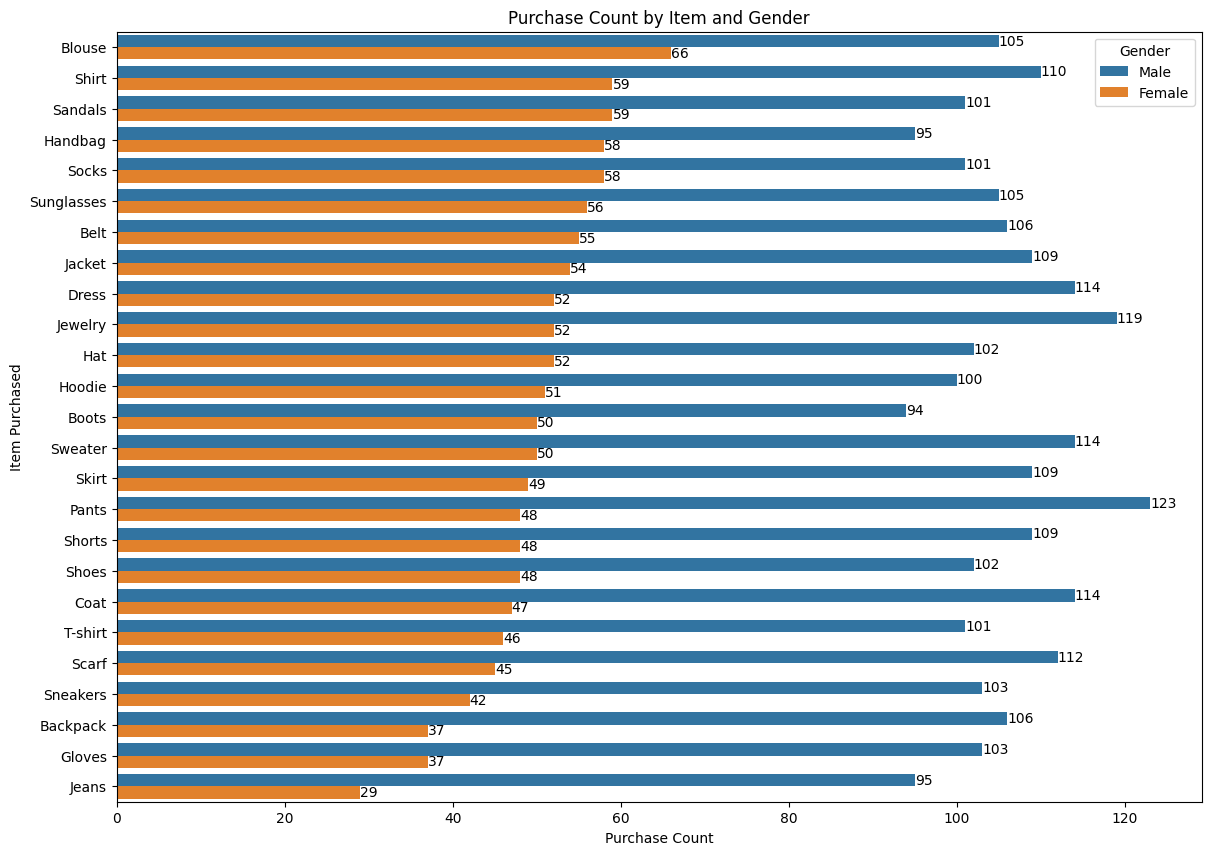

In [51]:
item_counts = (
    df.groupby("Gender")["Item Purchased"].value_counts().reset_index(name="Purchase Count")
)

plt.figure(figsize=(14,10))

item_revenue=sns.barplot(x="Purchase Count", y="Item Purchased", hue="Gender", hue_order=["Male", "Female"],data=item_counts, errorbar=None)
plt.title("Purchase Count by Item and Gender")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

Can a trend be picked up between colour and season?

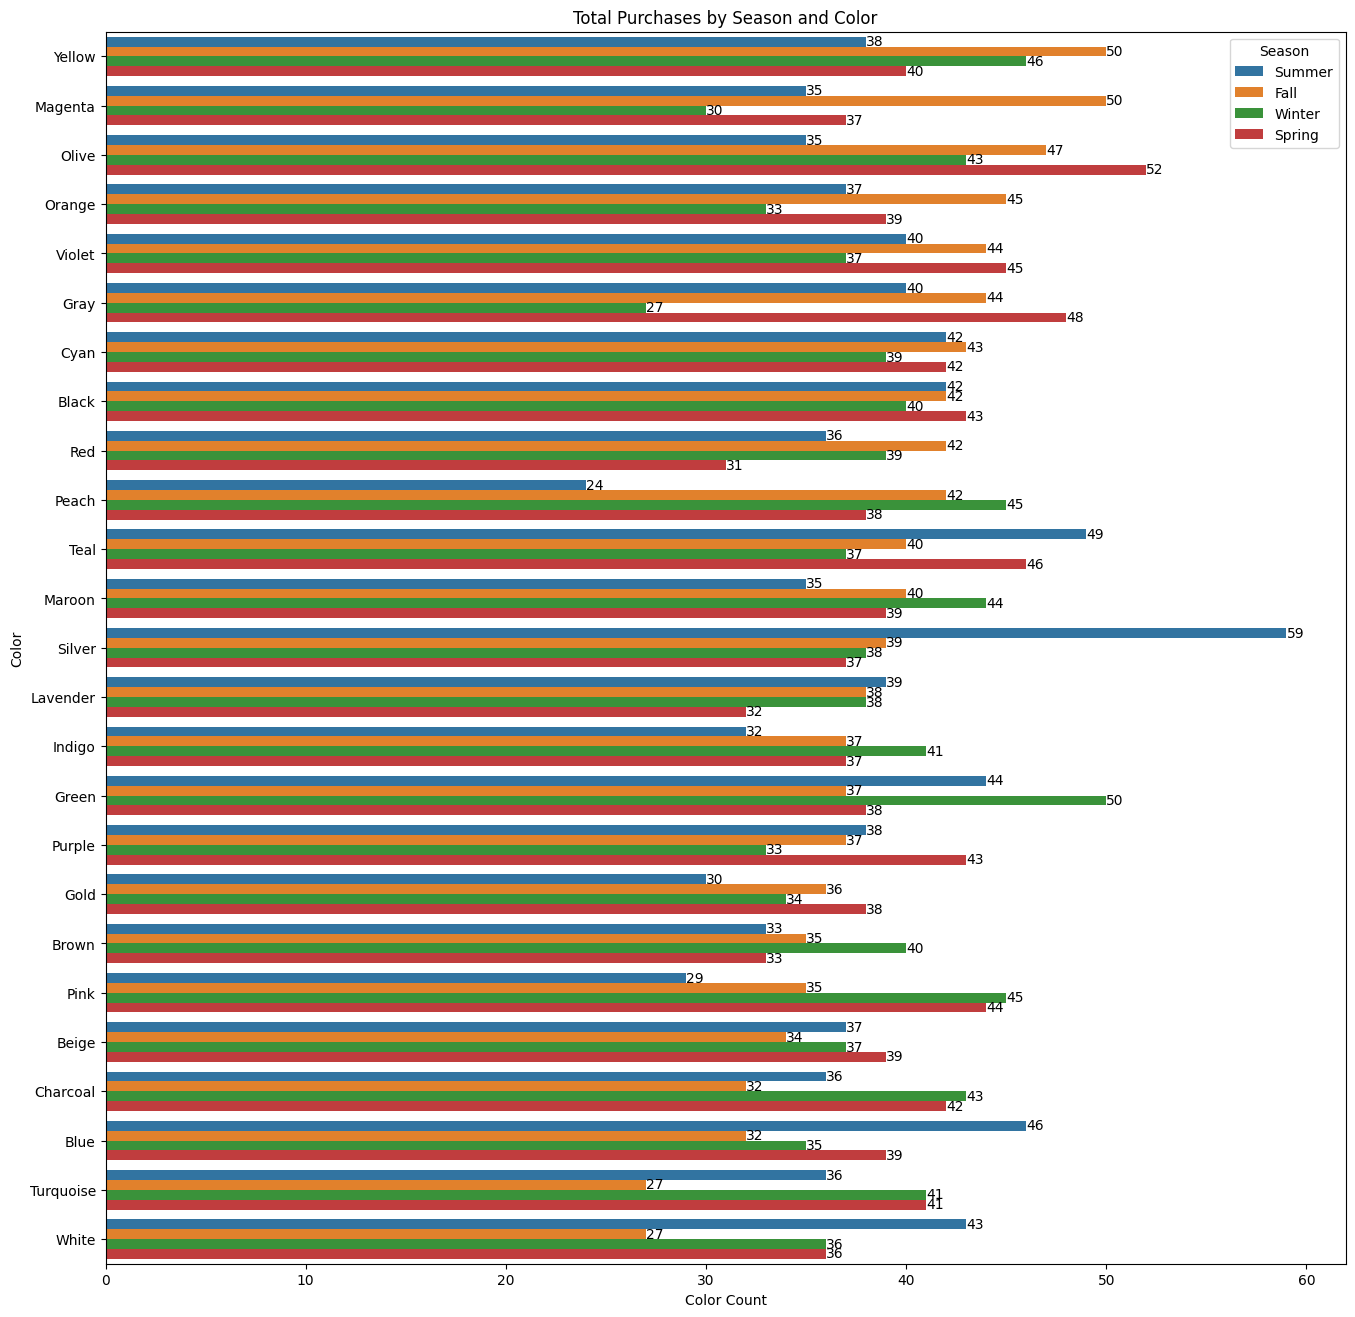

In [54]:
color_counts = (
    df.groupby("Season")["Color"].value_counts().reset_index(name="Color Count")
)

plt.figure(figsize=(16,16))

item_revenue=sns.barplot(x="Color Count", y="Color", hue="Season", hue_order=["Summer", "Fall", "Winter", "Spring"],data=color_counts, errorbar=None)
plt.title("Total Purchases by Season and Color")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

Its difficult to pick any trends in the Color vs Season plot due to how congested the graph is. A better option would be to create 4 plots separated by season.

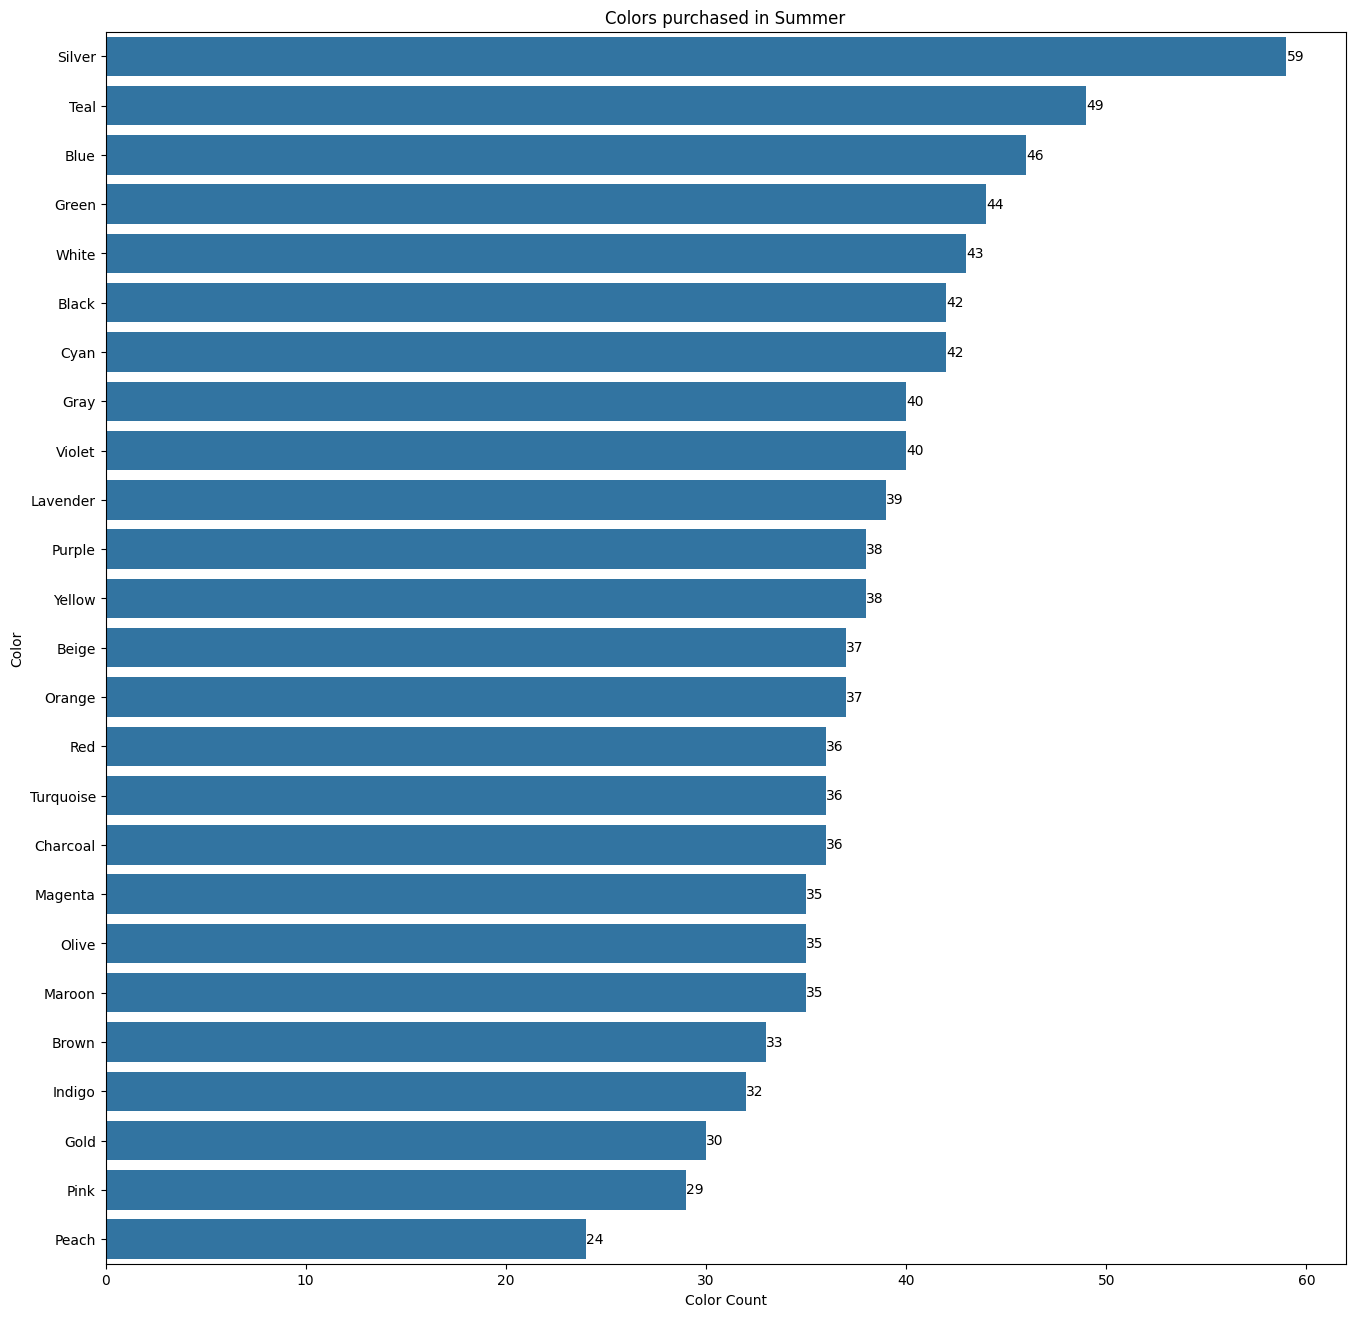

In [62]:
color_counts_by_season = (
    df.groupby("Season")["Color"].value_counts().reset_index(name="Color Count")
)
# color_counts_by_season
filtered_data = color_counts_by_season[color_counts_by_season['Season'].isin(['Summer'])]
plt.figure(figsize=(16,16))

item_revenue=sns.barplot(x="Color Count", y="Color",data=filtered_data, errorbar=None)
plt.title("Colors purchased in Summer")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

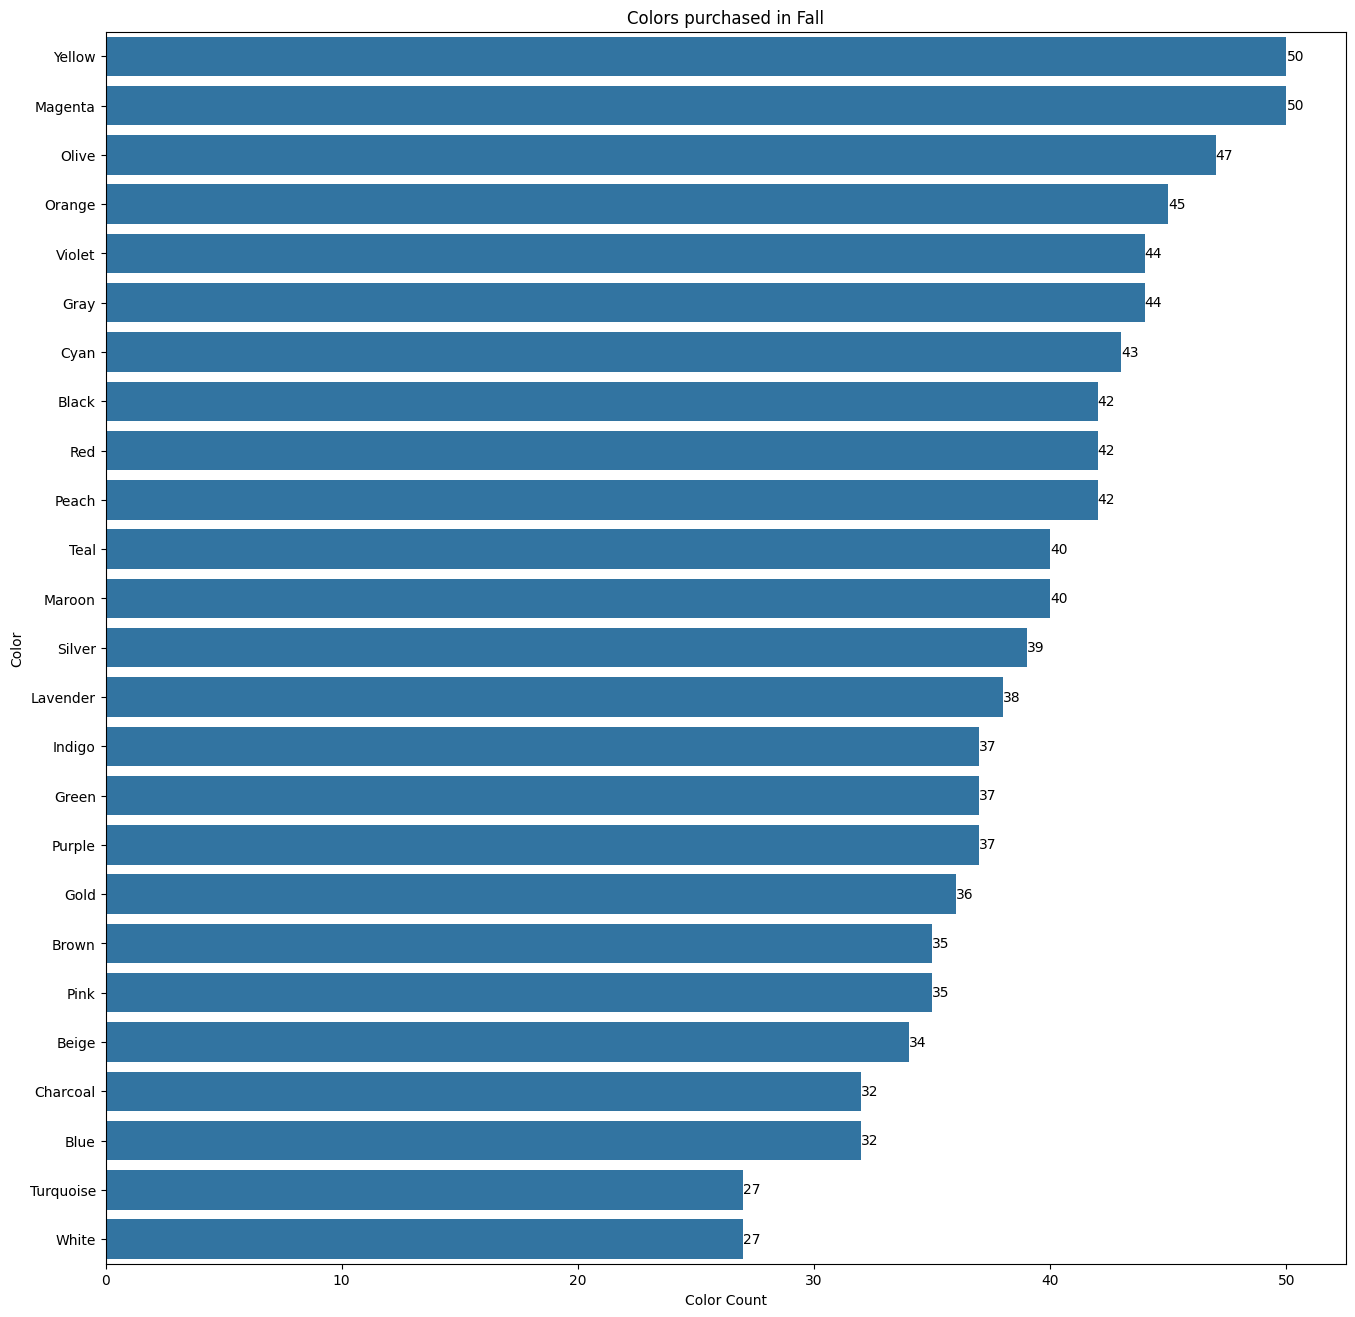

In [59]:
filtered_data = color_counts_by_season[color_counts_by_season['Season'].isin(['Fall'])]
plt.figure(figsize=(16,16))

item_revenue=sns.barplot(x="Color Count", y="Color",data=filtered_data, errorbar=None)
plt.title("Colors purchased in Fall")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

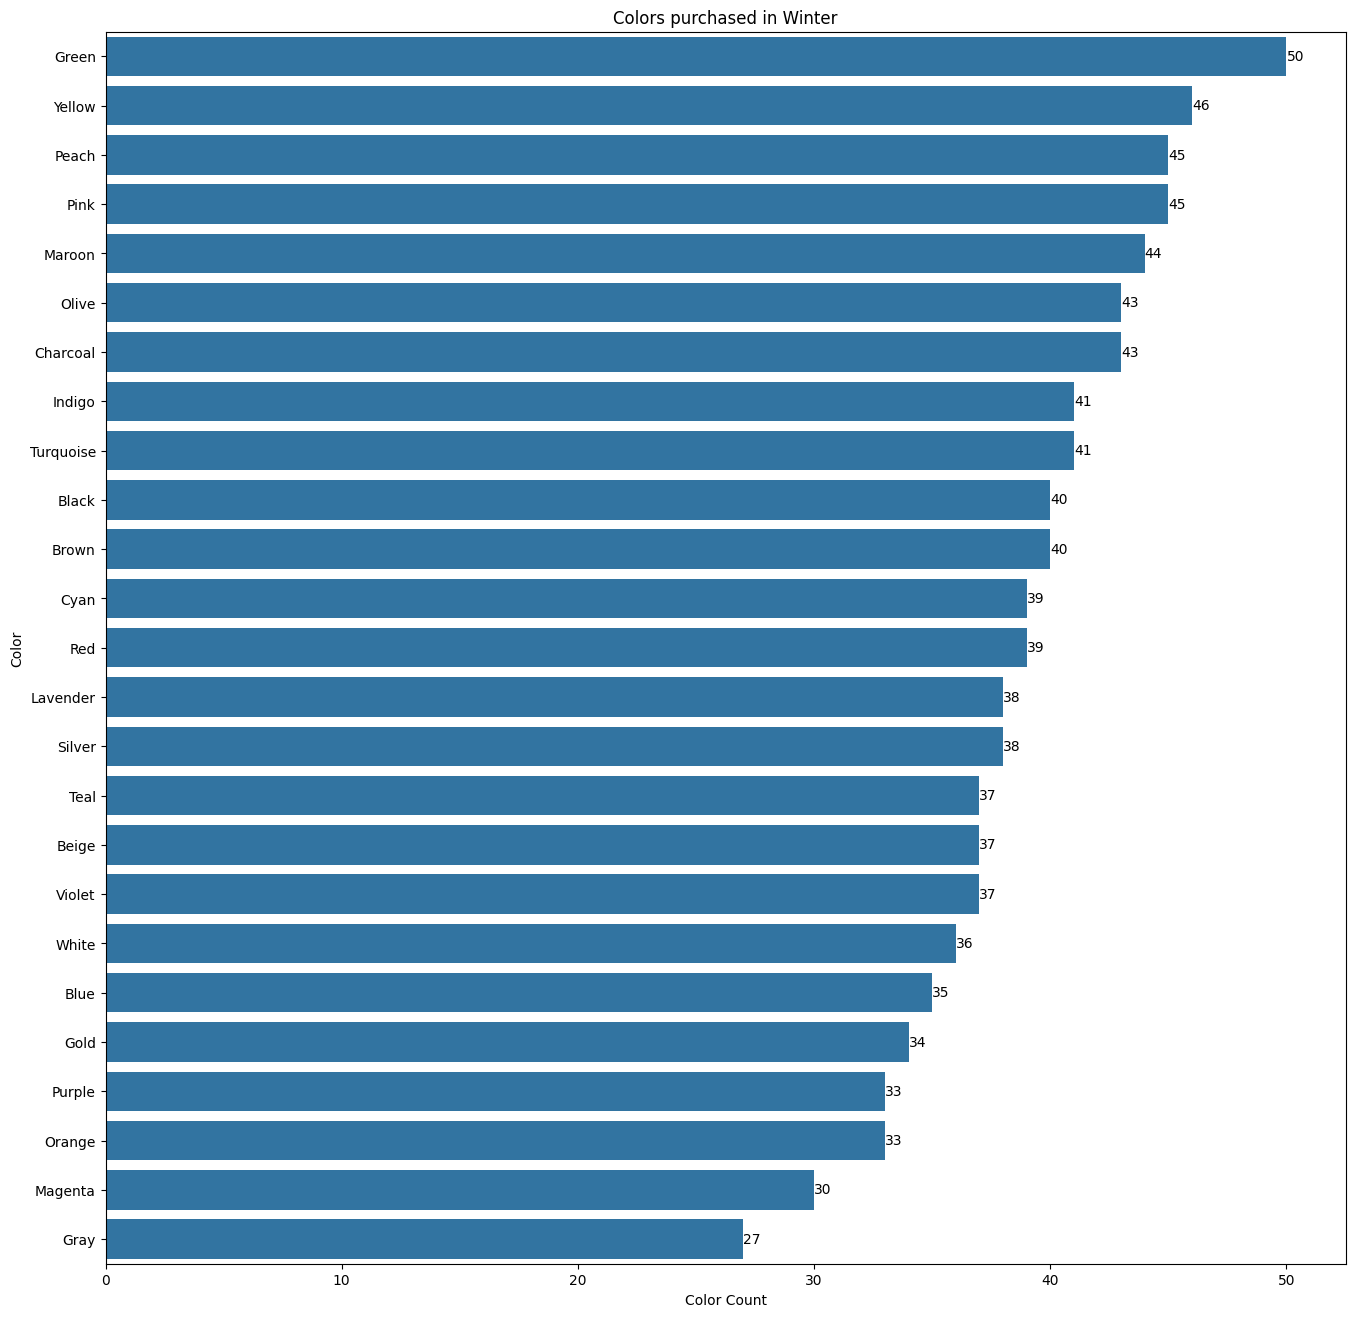

In [60]:
filtered_data = color_counts_by_season[color_counts_by_season['Season'].isin(['Winter'])]
plt.figure(figsize=(16,16))

item_revenue=sns.barplot(x="Color Count", y="Color",data=filtered_data, errorbar=None)
plt.title("Colors purchased in Winter")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

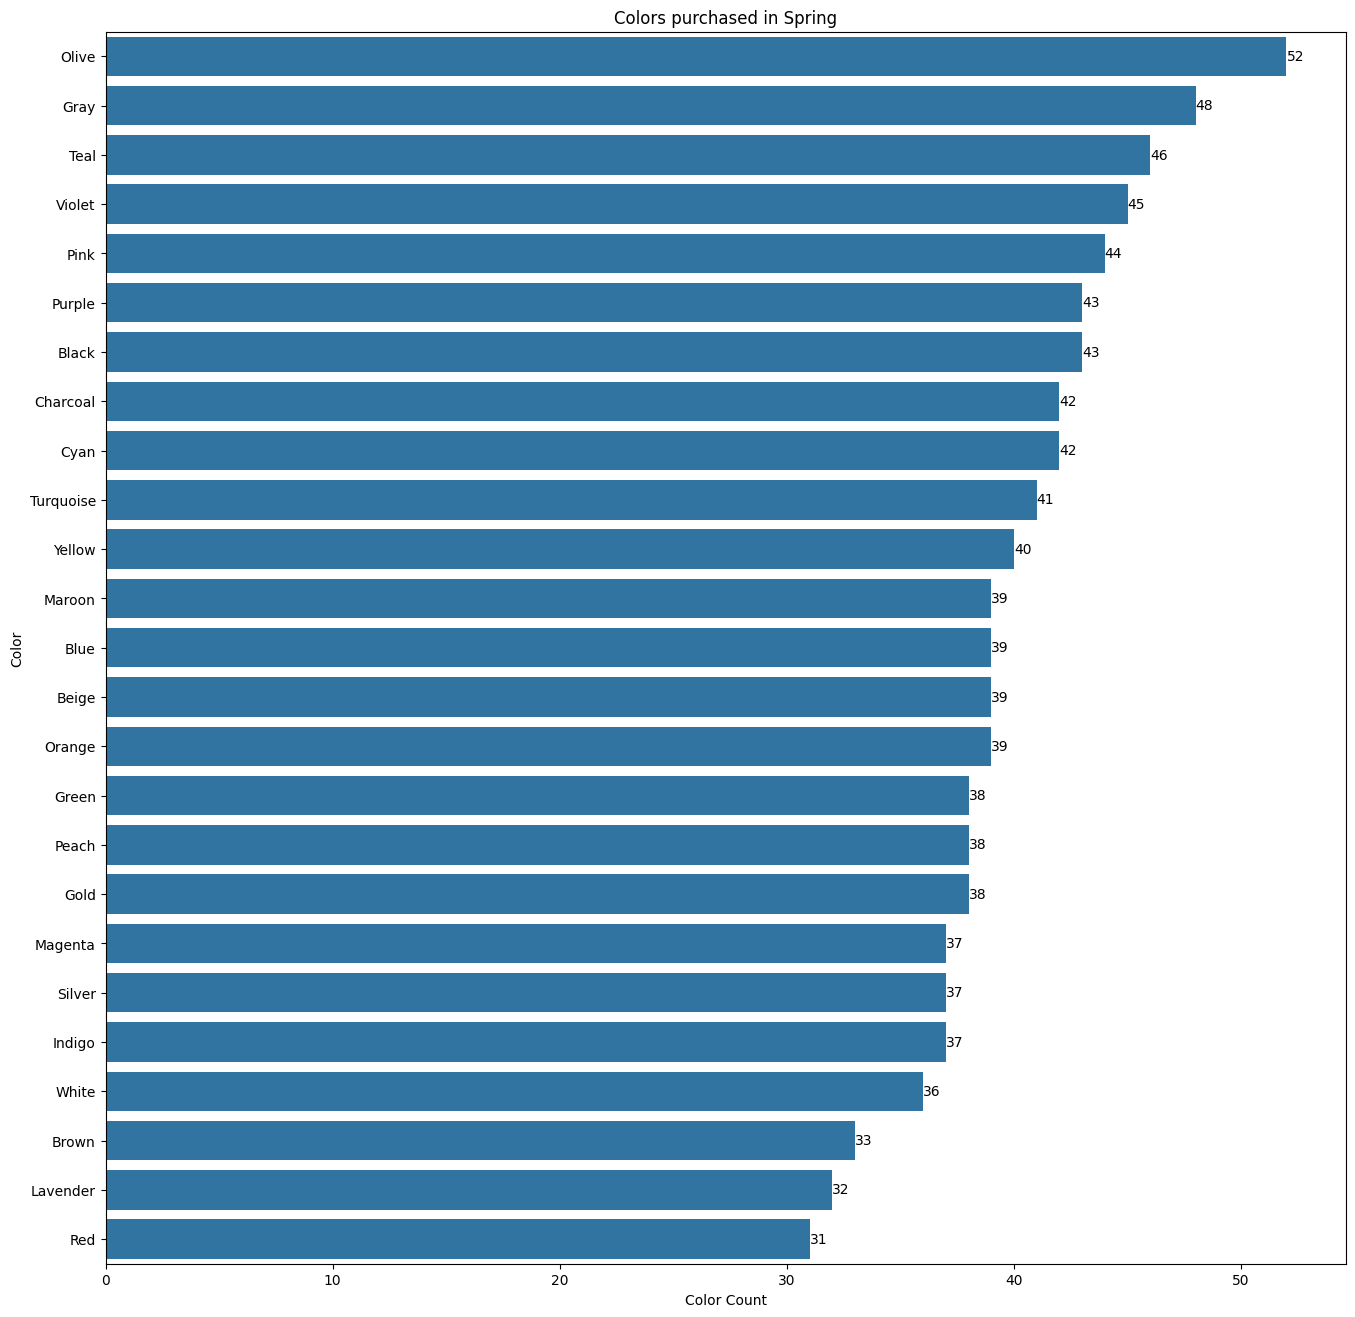

In [61]:
filtered_data = color_counts_by_season[color_counts_by_season['Season'].isin(['Spring'])]
plt.figure(figsize=(16,16))

item_revenue=sns.barplot(x="Color Count", y="Color",data=filtered_data, errorbar=None)
plt.title("Colors purchased in Spring")
for container in item_revenue.containers:
    item_revenue.bar_label(container)
plt.show()

3. Customer distribution 

How many unique customers do we have?

In [88]:
df["Customer ID"].nunique()

3900

Customer Location

In [52]:
df["Location"].value_counts()

Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont           85
Louisiana         84
North Dakota      83
West Virginia     81
Missouri          81
New Mexico        81
Mississippi       80
Kentucky          79
Arkansas          79
Indiana           79
Georgia           79
North Carolina    78
Connecticut       78
Maine             77
Texas             77
Tennessee         77
Ohio              77
Virginia          77
South Carolina    76
Oklahoma          75
Colorado          75
Wisconsin         75
Oregon            74
Pennsylvania      74
Washington        73
Michigan          73
Massachusetts     72
Alaska            72
Wyoming           71
New Hampshire     71
Utah              71
South Dakota      70
Iowa              69
Florida           68
New Jersey        67
Hawaii            65
Ariz

The list of locations being so long makes the output of the value_counts function difficult to investigate or interpret. A better way to investigate the customer distributions in all states would be to create a visualisation in the form of a heat map. This can be done using geopandas

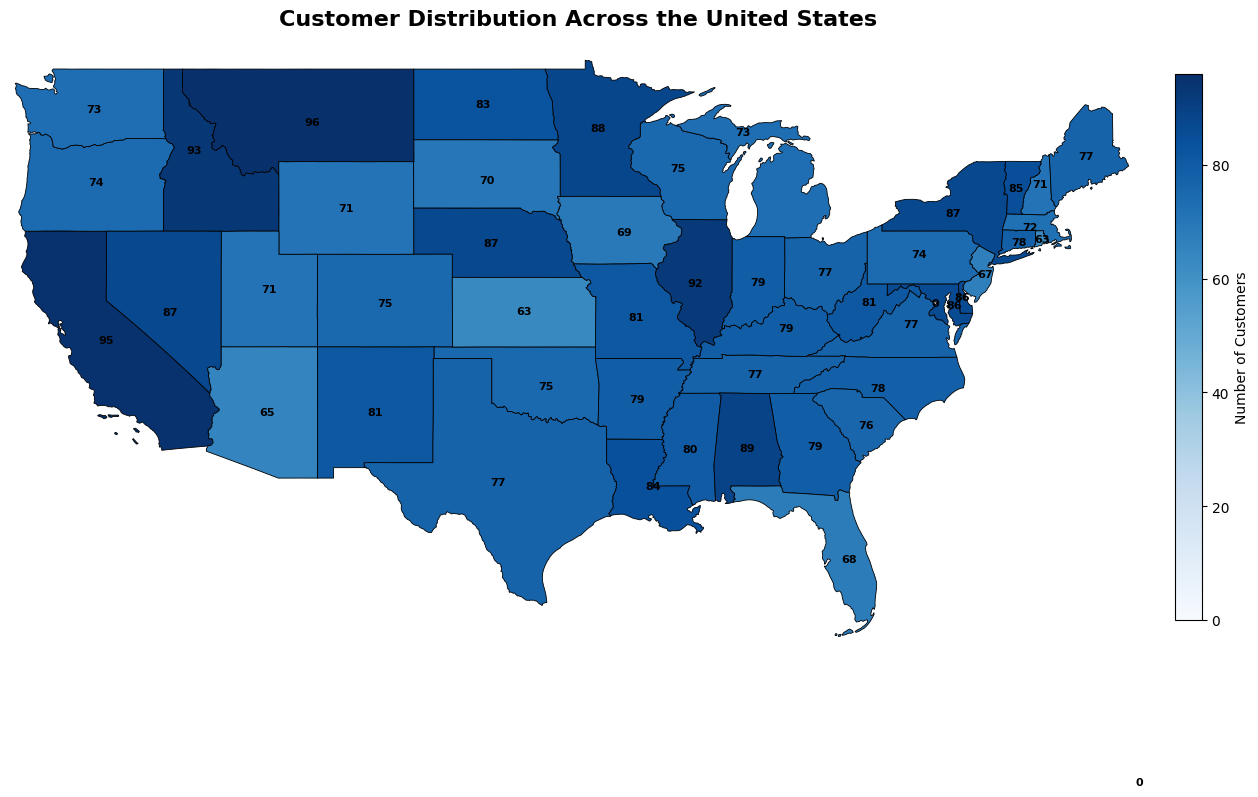

In [ ]:
import geopandas as gpd

customer_counts = (
    df.groupby("Location").size().reset_index(name="Customer Count")
)

states = gpd.read_file(
    "/data/raw/cb_2025_us_state_20m/cb_2025_us_state_20m.shp"
)

states = states[
    ~states["STUSPS"].isin(["AK", "HI"])
].copy()

states = states.merge(
    customer_counts,
    left_on="NAME",
    right_on="Location",
    how="left"
)

states["Customer Count"] = states["Customer Count"].fillna(0)

fig, ax = plt.subplots(figsize=(14, 8))

states.plot(
    column="Customer Count",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Number of Customers",
        "shrink": 0.75,
        "pad": 0.02
    },
    ax=ax
)

for idx, row in states.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        f"{int(row['Customer Count'])}",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold"
    )

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title(
    "Customer Distribution Across the United States",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.axis("off")

plt.tight_layout()

plt.show()

You could also represent the data graphically in the form of a bar chart.

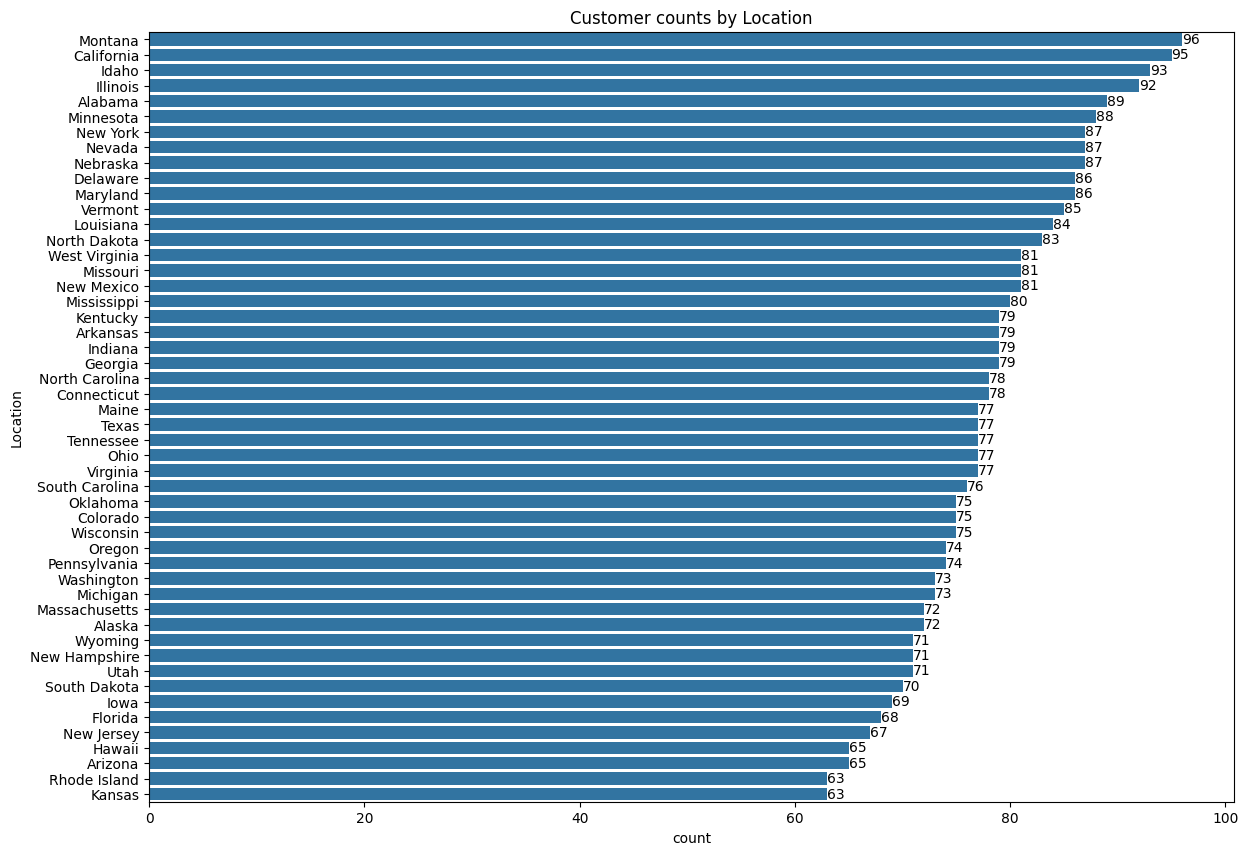

In [72]:
customer_counts= df["Location"].value_counts()
customer_counts_df = customer_counts.to_frame()
# print(customer_counts_df.head())

plt.figure(figsize=(14,10))

customer_counts_plot = sns.barplot(data=customer_counts_df, x="count", y="Location")
plt.title("Customer counts by Location")
for container in customer_counts_plot.containers:
    customer_counts_plot.bar_label(container)
plt.show()

3. What is the average customer's age in the different locations?

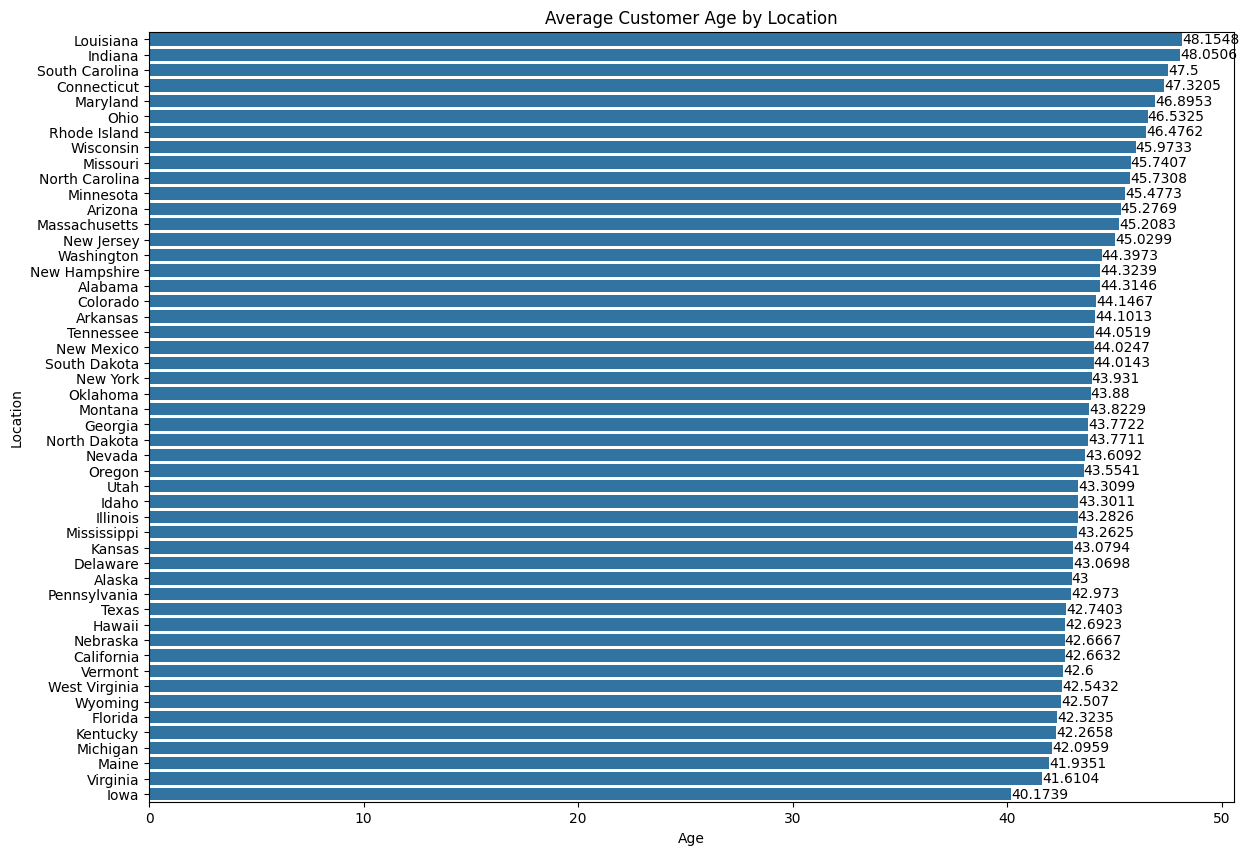

In [15]:
average_customer_age= df.groupby("Location")["Age"].mean()
average_customer_age_df = average_customer_age.to_frame()
# print(average_customer_age_df.head())
average_customer_age_df.sort_values(by="Age", ascending=False, inplace=True)

plt.figure(figsize=(14,10))

average_age_plot = sns.barplot(data=average_customer_age_df, x="Age", y="Location", order=average_customer_age_df.index)
plt.title("Average Customer Age by Location")
for container in average_age_plot.containers:
    average_age_plot.bar_label(container)
plt.show()

What about the total revenue by customer gender and location?

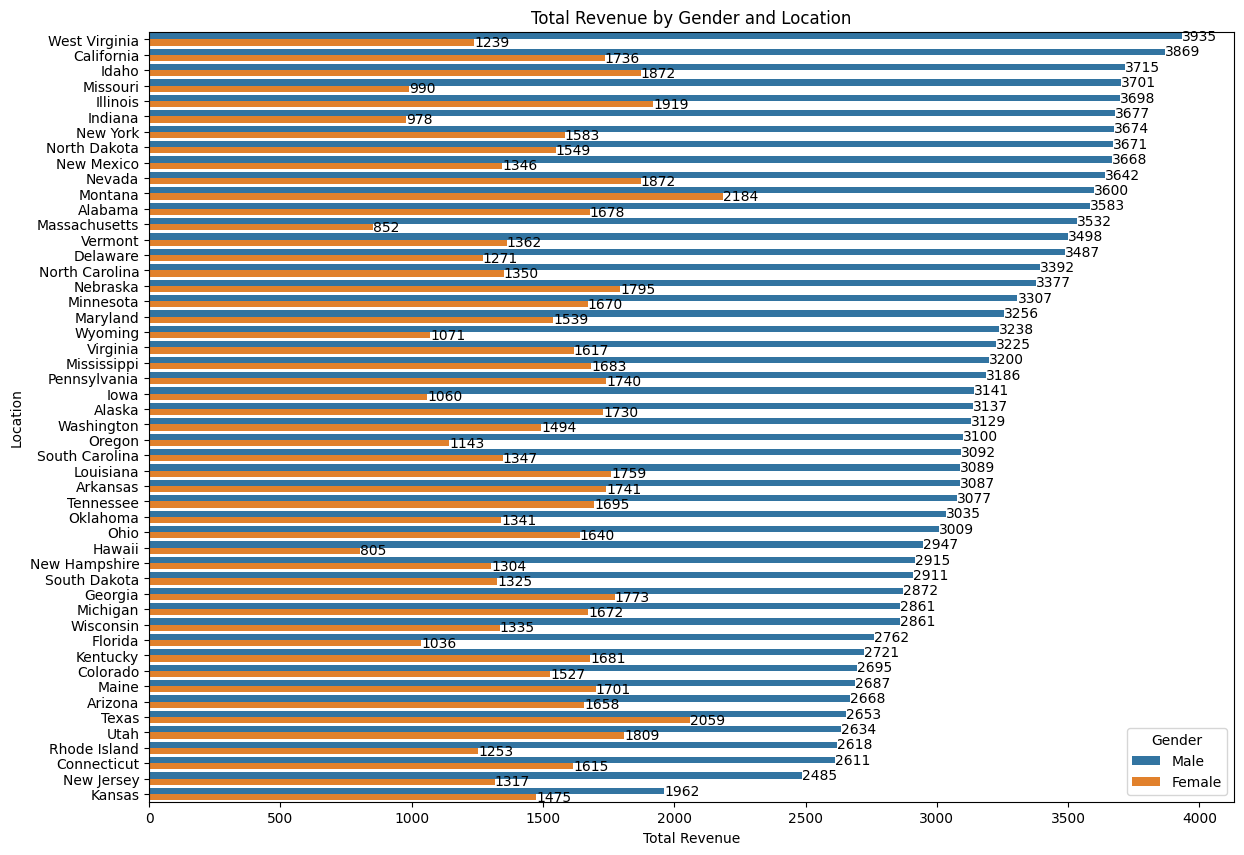

In [27]:
totalrev_by_gender_location = (
    df.groupby(["Location", "Gender"], as_index=False)["Purchase Amount (USD)"]
      .sum()
      .rename(columns={"Purchase Amount (USD)": "Total Revenue"})
)

totalrev_by_gender_location.sort_values(by="Total Revenue", ascending=False, inplace=True)

plt.figure(figsize=(14,10))

total_rev_plot = sns.barplot(
    data=totalrev_by_gender_location,
    x="Total Revenue",
    y="Location",
    hue="Gender",
    hue_order=["Male", "Female"],
    errorbar=None,
)
plt.title("Total Revenue by Gender and Location")
for container in total_rev_plot.containers:
    total_rev_plot.bar_label(container)
plt.show()

It has already become apparent that we have a larger male customer base than a female customer base. investigating this discrepancy further could lead to more insight. 

Customer Gender by Location

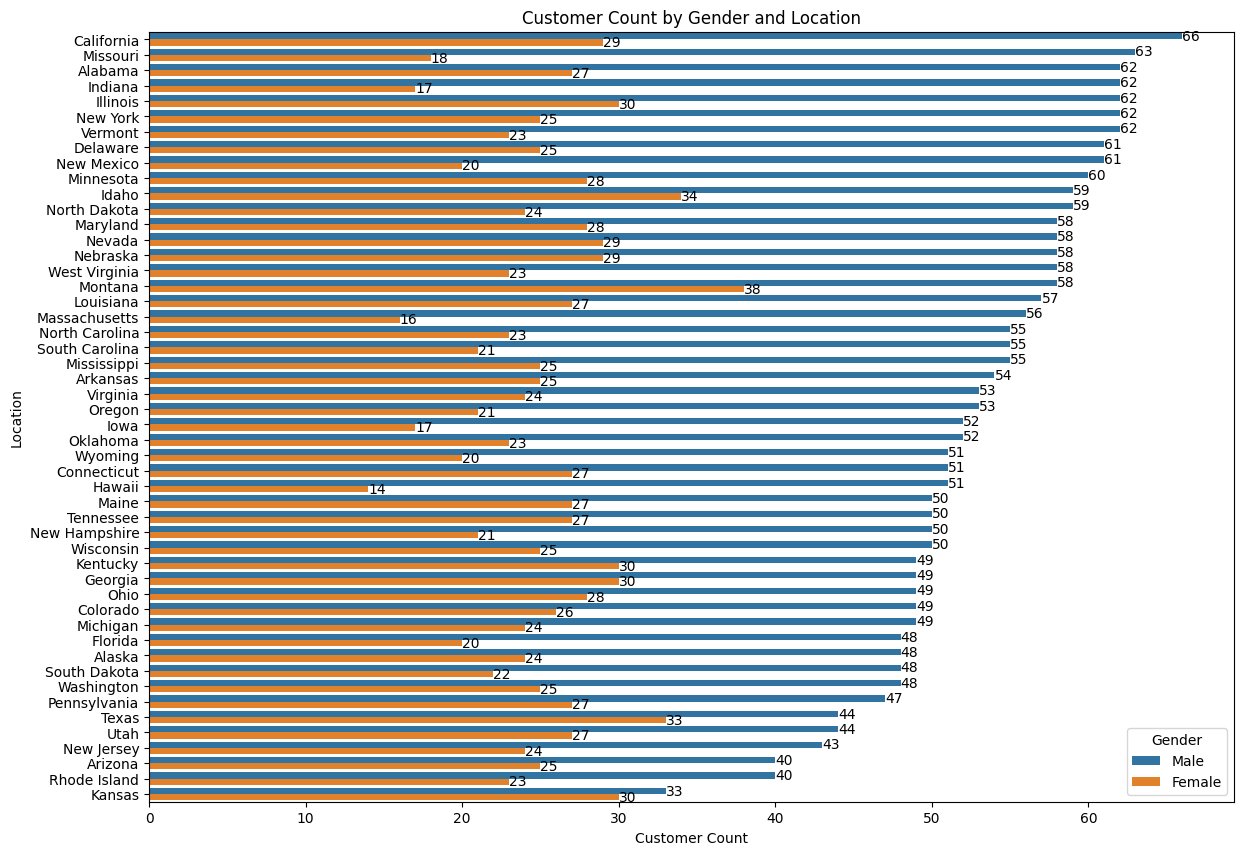

In [33]:
customer_gender_by_loc = (
    df.groupby(["Location", "Gender"], as_index=False)
      .size()
      .rename(columns={"size": "Customer Count"})
)

customer_gender_by_loc.sort_values(by="Customer Count", ascending=False, inplace=True)

plt.figure(figsize=(14,10))

total_rev_plot = sns.barplot(
    data=customer_gender_by_loc,
    x="Customer Count",
    y="Location",
    hue="Gender",
    hue_order=["Male", "Female"],
    errorbar=None,
)
plt.title("Customer Count by Gender and Location")
for container in total_rev_plot.containers:
    total_rev_plot.bar_label(container)
plt.show()

4. Behavioural insights 

In [13]:
df.groupby(["Gender", "Category"])["Purchase Amount (USD)"].mean()

Gender  Category   
Female  Accessories    60.762755
        Clothing       60.496403
        Footwear       59.472362
        Outerwear      58.425743
Male    Accessories    59.411557
        Clothing       59.803556
        Footwear       60.645000
        Outerwear      56.605381
Name: Purchase Amount (USD), dtype: float64

In [14]:
df.groupby(["Gender", "Category"])["Purchase Amount (USD)"].max()

Gender  Category   
Female  Accessories    100
        Clothing       100
        Footwear        99
        Outerwear      100
Male    Accessories    100
        Clothing       100
        Footwear       100
        Outerwear      100
Name: Purchase Amount (USD), dtype: int64

In [19]:
df.groupby(["Gender", "Category"])["Purchase Amount (USD)"].sum()

Gender  Category   
Female  Accessories    23819
        Clothing       33636
        Footwear       11835
        Outerwear       5901
Male    Accessories    50381
        Clothing       70628
        Footwear       24258
        Outerwear      12623
Name: Purchase Amount (USD), dtype: int64

In [15]:
df.groupby(["Gender", "Category"])["Purchase Amount (USD)"].min()

Gender  Category   
Female  Accessories    20
        Clothing       20
        Footwear       20
        Outerwear      20
Male    Accessories    20
        Clothing       20
        Footwear       20
        Outerwear      20
Name: Purchase Amount (USD), dtype: int64

In [20]:
df.groupby(["Gender", "Season"])["Purchase Amount (USD)"].sum()

Gender  Season
Female  Fall      20193
        Spring    18578
        Summer    18060
        Winter    18360
Male    Fall      39825
        Spring    40101
        Summer    37717
        Winter    40247
Name: Purchase Amount (USD), dtype: int64

In [21]:
df.groupby(["Gender", "Season"])["Purchase Amount (USD)"].mean()

Gender  Season
Female  Fall      61.564024
        Spring    58.791139
        Summer    60.604027
        Winter    60.000000
Male    Fall      61.553323
        Spring    58.713031
        Summer    57.407915
        Winter    60.521805
Name: Purchase Amount (USD), dtype: float64

In [76]:
df.groupby(["Gender", "Location"])["Purchase Amount (USD)"].mean()

Gender  Location     
Female  Alabama          62.148148
        Alaska           72.083333
        Arizona          66.320000
        Arkansas         69.640000
        California       59.862069
                           ...    
Male    Virginia         60.849057
        Washington       65.187500
        West Virginia    67.844828
        Wisconsin        57.220000
        Wyoming          63.490196
Name: Purchase Amount (USD), Length: 100, dtype: float64

In [81]:
df.groupby(["Gender"])["Discount Applied"].value_counts()

Gender  Discount Applied
Female  No                  1248
Male    Yes                 1677
        No                   975
Name: count, dtype: int64

Is there a statistically significant difference in the category purchased from the use of a promo code?

In [43]:
table = pd.crosstab(df["Promo Code Used"], df["Category"])
table

Category,Accessories,Clothing,Footwear,Outerwear
Promo Code Used,,,,
No,697,1006,340,180
Yes,543,731,259,144


In [44]:
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

Chi-square statistic: 1.200
P-value: 0.75293
Degrees of freedom: 3
Expected frequencies:
[[706.8  990.09 341.43 184.68]
 [533.2  746.91 257.57 139.32]]


Since the p-value > 0,05 we can conclude that the Category purchased from does not have a statistically significant impact on the usage of Promo Codes.

Is there a statistically significant difference between the item purchased and the use of a promo code?

In [45]:
table = pd.crosstab(df["Promo Code Used"], df["Item Purchased"])
table

Item Purchased,Backpack,Belt,Blouse,Boots,Coat,Dress,Gloves,Handbag,Hat,Hoodie,...,Scarf,Shirt,Shoes,Shorts,Skirt,Sneakers,Socks,Sunglasses,Sweater,T-shirt
Promo Code Used,,,,,,,,,,,,,,,,,,,,,
No,79,89,113,77,82,91,80,92,77,83,...,90,98,89,89,97,73,107,95,85,86
Yes,64,72,58,67,79,75,60,61,77,68,...,67,71,61,68,61,72,52,66,79,61


In [46]:
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

Chi-square statistic: 31.910
P-value: 0.12924
Degrees of freedom: 24
Expected frequencies:
[[81.51 91.77 97.47 82.08 91.77 94.62 79.8  87.21 87.78 86.07 92.91 70.68
  97.47 97.47 91.2  89.49 96.33 85.5  89.49 90.06 82.65 90.63 91.77 93.48
  83.79]
 [61.49 69.23 73.53 61.92 69.23 71.38 60.2  65.79 66.22 64.93 70.09 53.32
  73.53 73.53 68.8  67.51 72.67 64.5  67.51 67.94 62.35 68.37 69.23 70.52
  63.21]]


Since the p-value > 0,05 we can conclude that the item purchased does not have a statistically significant impact on the usage of Promo Codes.

Does gender influence the usage of promo codes?

In [47]:
table = pd.crosstab(df["Promo Code Used"], df["Gender"])
table

Gender,Female,Male
Promo Code Used,,
No,1248,975
Yes,0,1677


In [48]:
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

Chi-square statistic: 1381.941
P-value: 0.00000
Degrees of freedom: 1
Expected frequencies:
[[ 711.36 1511.64]
 [ 536.64 1140.36]]


Gender does have an influence on the usage of Promo Codes.

5. Correlation Analysis 

In [89]:
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

Is there an association between Purchase Amount and Age?

In [95]:
from scipy.stats import spearmanr

r, p = spearmanr(
    df["Purchase Amount (USD)"],
    df["Age"]
)

print("Spearman r:", r)
print("p-value:", p)

Spearman r: -0.010444519559151589
p-value: 0.5143568334160392


The correlation coefficient is extremely weak and negative. The p-value is greater than 0.05. The association between age and purchasing amount is not only weak but statistically insignificant. Older customers do not appear to spend more than younger customers.

Is customer review rating associated with item purchased?

In [34]:
r, p = spearmanr(
    df["Item Purchased"],
    df["Review Rating"]
)

print("Spearman r:", r)
print("p-value:", p)

NameError: name 'spearmanr' is not defined

The p-value is greater than 0.05 therefore there a statistically insignificant association between review ratings and purchase amount. The correlation coefficient is positive but weak. This suggests that This suggests that review ratings could be associated with quality of the items or customer experience in store or when shopping online rather than how much the customer spends.

Is the number of previous purchases associated with purchasing amount?

In [97]:
r, p = spearmanr(
    df["Purchase Amount (USD)"],
    df["Previous Purchases"]
)

print("Spearman r:", r)
print("p-value:", p)

Spearman r: 0.008314955953859364
p-value: 0.6036830945527644


The p-value is greater than 0.05 therefore the association between previous purchases and purchase amount is statistically insignificant. This  suggests that customers with purchasing history do not generate higher transaction values.

Are repeat customers more satisfied with items purchased?

In [98]:
r, p = spearmanr(
    df["Review Rating"],
    df["Previous Purchases"]
)

print("Spearman r:", r)
print("p-value:", p)

Spearman r: 0.004438264035333068
p-value: 0.7817171311489961


The p-value is greater than 0.05 therefore the association between previous purchases and review ratings is statistically insignificant. This could give an indication of customer dissatisfaction 

Is customer loyalty concentrated within a particular age group?

In [99]:
r, p = spearmanr(
    df["Age"],
    df["Previous Purchases"]
)

print("Spearman r:", r)
print("p-value:", p)

Spearman r: 0.040512827982805394
p-value: 0.01139803020811944


The p-value is less than 0.05 therefore the association between previous purchases and age is statistically significant. However, the spearman's rho coefficient between the variables is only 0.04 which is very weak. This is an example of a statistically significant result that does not have significant business impact.

Does customer satisfaction vary systematically with age ?

In [100]:
r, p = spearmanr(
    df["Age"],
    df["Review Rating"]
)

print("Spearman r:", r)
print("p-value:", p)

Spearman r: -0.021968538033965767
p-value: 0.17016915148089126


The p-value is greater than 0.05 therefore the association between  age and review ratings is statistically insignificant. There seems to be no demographic differences in customer experience.

Does customer satisfaction vary systematically with gender?

In [5]:
table = pd.crosstab(df["Gender"], df["Review Rating"])
table

Review Rating,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
Gender,,,,,,,,,,,,,,,,,,,,,
Female,22,53,46,52,51,50,53,51,48,61,...,43,55,52,45,41,54,41,43,60,25
Male,44,106,108,84,119,112,104,101,104,121,...,105,116,95,113,98,120,107,101,106,43


In [7]:
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 18.306
P-value: 0.82914


The p-value is greater than 0.05 therefore the association between gender and review ratings is statistically insignificant. 

In [3]:
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

Does customer satisfaction vary systematically with location?

In [8]:
table = pd.crosstab(df["Location"], df["Review Rating"])
table

Review Rating,2.5,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
Location,,,,,,,,,,,,,,,,,,,,,
Alabama,0,9,1,4,1,2,4,6,3,3,...,7,7,6,3,3,1,5,4,3,2
Alaska,3,1,3,1,6,2,1,3,3,5,...,2,6,3,2,4,7,3,3,0,3
Arizona,1,5,4,1,4,1,4,4,1,3,...,0,3,3,6,1,5,1,2,3,0
Arkansas,1,4,3,5,4,2,4,1,3,6,...,3,2,4,3,4,4,3,2,3,1
California,2,1,3,0,2,7,4,6,4,5,...,1,4,4,4,4,3,8,1,4,4
Colorado,1,3,5,0,5,3,6,1,2,5,...,3,6,3,3,2,1,5,4,2,0
Connecticut,1,4,7,5,3,2,4,0,0,4,...,5,2,1,5,4,3,2,3,3,1
Delaware,2,5,3,2,1,3,2,5,7,3,...,1,4,4,2,4,4,3,4,6,2
Florida,2,3,2,2,5,2,2,5,4,3,...,3,3,2,3,3,6,1,2,1,0


In [9]:
chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.5f}")

Chi-square statistic: 1153.474
P-value: 0.92794


The p-value is greater than 0.05 therefore the association between location and review ratings is statistically insignificant. This location/review ratings matrix is however a matrix of interest. One can 

The p-value is greater than 0.05 therefore the association between  age and review ratings is statistically insignificant. There seems to be no demographic differences in customer experience.

Do subscribers spend more?